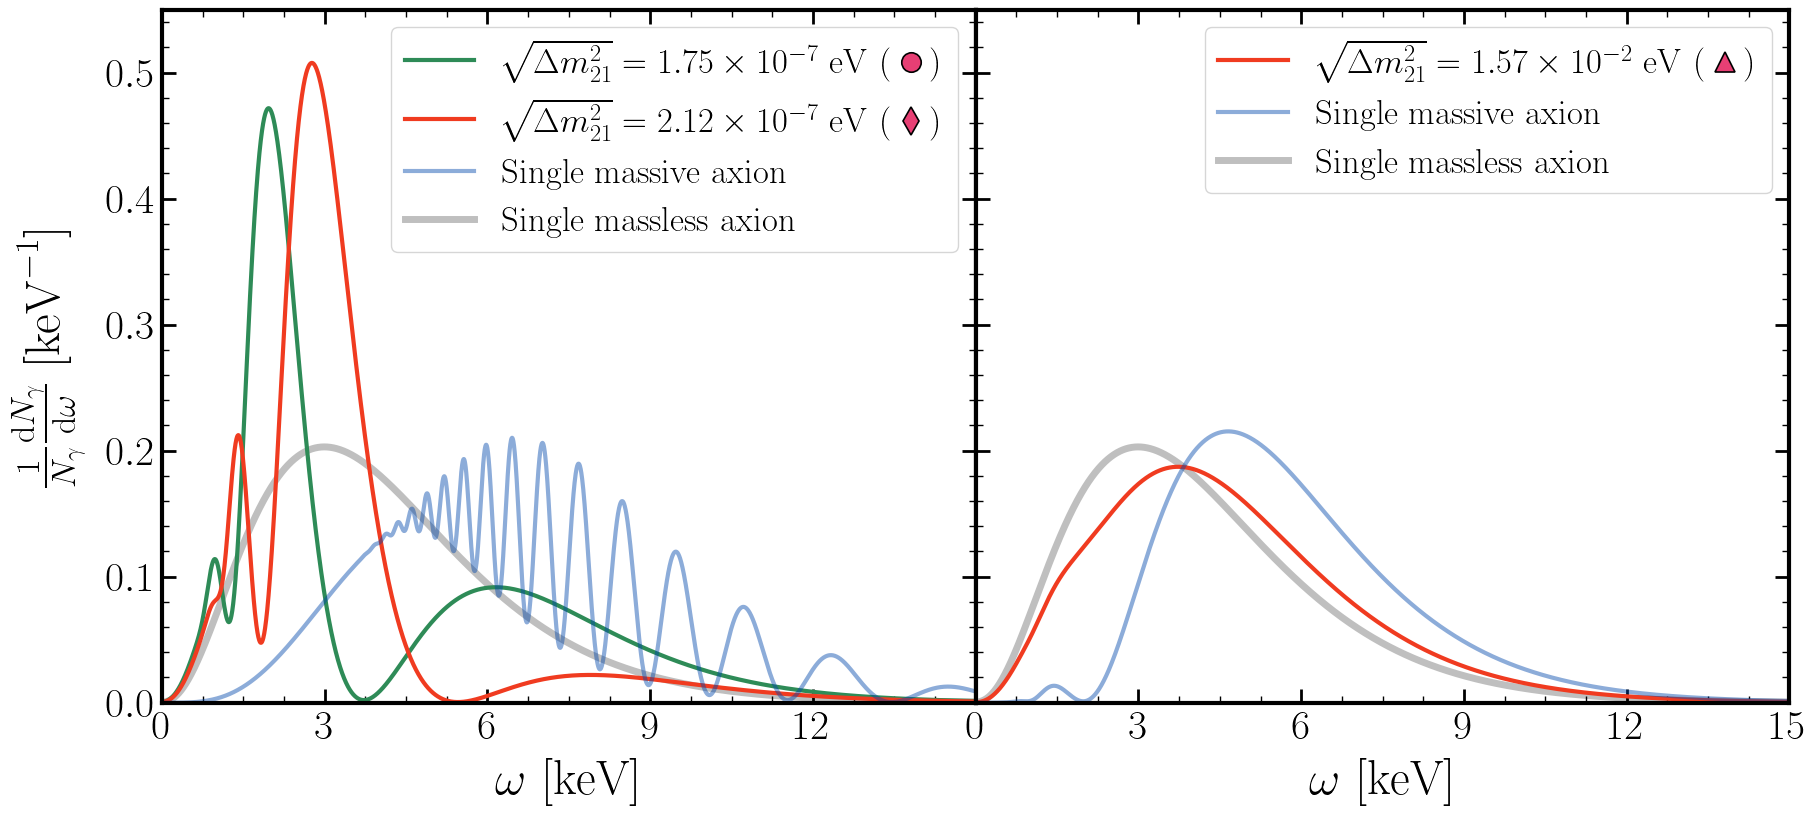

In [67]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
from matplotlib.lines import Line2D
from Functions_Binned_Analysis import dNdw, IAXO, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":30,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":3,
   "lines.linewidth":3,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[21,9],
   "savefig.dpi":300,
   "savefig.transparent":True
})

reds = YlOrRd_5.mpl_colors
colors = Bold_10.mpl_colors

def add_marker_to_legend_text(fig,legend,text_index,color,marker='o',markersize=12,edgecolor='black',dx_px=18):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    txt = legend.get_texts()[text_index]
    bbox = txt.get_window_extent(renderer=renderer)
    y_disp = 0.5 * (bbox.y0 + bbox.y1)
    x_disp = bbox.x1 - dx_px
    x_fig, y_fig = fig.transFigure.inverted().transform((x_disp, y_disp))
    artist = Line2D(
        [x_fig], [y_fig],
        marker=marker,
        linestyle='None',
        markersize=markersize,
        markerfacecolor=color,
        markeredgecolor=edgecolor,
        markeredgewidth=1.2,
        transform=fig.transFigure,
        zorder=10000
    )
    fig.add_artist(artist)
    return artist

w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
w = np.linspace(w_min,w_max,5000) # [keV]
g = 1e-11 # [GeV^-1]
exp = IAXO
L_source = L_ES
res_on = True
w_res = 100e-3 # [keV]

fig = plt.figure()
gs = gridspec.GridSpec(1,2,wspace=0)
axL = fig.add_subplot(gs[0,0])
axR = fig.add_subplot(gs[0,1])

#==============================================================================#

# 2-axion quasi-degenerate and "massless"
m2 = 1e-3 # [eV]
delta_m21_sq = (1.75e-7)**2 # [eV^2]
mixing = np.pi/4.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axL.plot(w,spectrum/N,label=r'$\sqrt{\Delta m_{21}^2} = 1.75\times 10^{-7}\ \mathrm{eV}\ (\quad\,)$',color='seagreen')

# 2-axion quasi-degenerate and "massless"
m2 = 1e-3 # [eV]
delta_m21_sq = (2.12e-7)**2 # [eV^2]
mixing = np.pi/4.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axL.plot(w,spectrum/N,label=r'$\sqrt{\Delta m_{21}^2} = 2.12\times 10^{-7}\ \mathrm{eV}\ (\quad\,)$',color=reds[3])

# 1-axion "massive"
m2 = 1e-1 # [eV]
delta_m21_sq = 0.0
mixing = 0.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axL.plot(w,spectrum/N,label=r'$\mathrm{Single\ massive\ axion}$',color="#0047AB",alpha=0.45)

# 1-axion "massless"
m2 = 1e-3 # [eV]
delta_m21_sq = 0.0
mixing = 0.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axL.plot(w,spectrum/N,label=r'$\mathrm{Single\ massless\ axion}$',color='gray',lw=5,alpha=0.5,zorder=0)


axL.set_xlim(left=0,right=15)
axL.set_xticks([0,3,6,9,12])
axL.set_ylim(bottom=0,top=0.55)
axL.tick_params(axis='x',which='major',pad=5)
axL.tick_params(axis='x',which='minor',pad=5)
axL.tick_params(axis='y',which='major',pad=5)
axL.tick_params(axis='y',which='minor',pad=5)
axL.set_xlabel(r"$\omega\ [\mathrm{keV}]$",fontsize=35,labelpad=8)
axL.set_ylabel(r"$\frac{1}{N_\gamma}\frac{\mathrm{d}N_\gamma}{\mathrm{d}\omega}\ [\mathrm{keV}^{-1}]$",fontsize=35,labelpad=15)
legL=axL.legend(fontsize=25,frameon=True)
legend_marker_artists = []
legend_marker_artists.append(
    add_marker_to_legend_text(
        fig, legL, text_index=0,
        color=colors[4], marker='o',
        markersize=14, dx_px=33
    )
)
legend_marker_artists.append(
    add_marker_to_legend_text(
        fig, legL, text_index=1,
        color=colors[4], marker='d',
        markersize=14, dx_px=33
    )
)

#==============================================================================#

# 2-axion hierarchical and one "massive"
m2 = 1.57e-2 # [eV]
delta_m21_sq = (1.57e-2)**2 # [eV^2]
mixing = np.pi/4.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axR.plot(w,spectrum/N,label=r'$\sqrt{\Delta m_{21}^2} = 1.57\times 10^{-2}\ \mathrm{eV}\ (\quad\,)$',color=reds[3])

# 1-axion "massive"
m2 = 1.57e-2 # [eV]
delta_m21_sq = 0.0
mixing = 0.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axR.plot(w,spectrum/N,label=r'$\mathrm{Single\ massive\ axion}$',color="#0047AB",alpha=0.45)

# 1-axion "massless"
m2 = 1e-3 # [eV]
delta_m21_sq = 0.0
mixing = 0.0
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
axR.plot(w,spectrum/N,label=r'$\mathrm{Single\ massless\ axion}$',color='gray',lw=5,alpha=0.5,zorder=0)

axR.set_xlim(left=0,right=15)
axR.set_xticks([0,3,6,9,12,15])
axR.set_ylim(bottom=0,top=0.55)
axR.tick_params(axis='x',which='major',pad=5)
axR.tick_params(axis='x',which='minor',pad=5)
axR.set_xlabel(r"$\omega\ [\mathrm{keV}]$",fontsize=35,labelpad=8)
axR.tick_params(axis='y',labelleft=False)
legR=axR.legend(fontsize=25,frameon=True)
legend_marker_artists.append(
    add_marker_to_legend_text(
        fig, legR, text_index=0,
        color=colors[4], marker='^',
        markersize=14, dx_px=33
    )
)

#==============================================================================#

fig.savefig("plots/Appendix_spectra.pdf",bbox_inches="tight")
fig.savefig("plots/Appendix_spectra.png",bbox_inches="tight")
plt.show()